# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra LO QUE MUESTRE EL NOTEBOOK utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el uso del dataset: ERA5-LAND

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para el uso del dataset: ERA5-LAND" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía tiene como objetivo ayudarte a entender y cargar el dataset ERA5-LAND, de manera que puedas sacar el máximo provecho de estos datos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

Esta guía pretende ayudarte a entender como cargar diferentes datasets, en concreto el de *ERA5-LAND*, permitiendo usar las diferentes variables en diferentes tipos de estudios, ya sea el cálculo de índices, análisis climáticos, etc. El objetivo principal es que comprendas de forma general la carga de datos y que puedas llevarlo a cabo en tus propias investigaciones. Se trata de un cuaderno que contiene conceptos básicos para poder entender y reproducir otros de manera más autodidácta. De esta manera vamos a **guiarte** a través de los pasos fundamentales para trabajar de manera efectiva con los datos este tipo de daatasets.

Tras la carga de datos, habrá bloques de visualizaciones, permitiendo familiarizarte con este tipo de análisis de resultados y permitiendote aprender diferentes tipos de representacionse. Para todo ello, se utilizará el **framework *climate4R***, un conjunto de librerías de R para la carga, post-procesamiento y análisis de datos climáticos. 


<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos y análisis básico

Empezamos dando la memoria que queramos a la RAM (la suficiente para poder cargar varios datasets)

In [1]:
options(java.parameters = "-Xmx14g")

### 1. Carga de librerías

Cargamos las librerías necesarias. Las tres primeras corresponden a librerías del framework *climate4R* y las tres últimas se usarán para mostrar las visualizaciones.

In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.3) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



### 2. Selección de conjuntos de datos  

Leemos el archivo donde se tiene el contenido de todos los datasets y vemos que pinta tiene para decidir que es lo que queremos cargar.

In [3]:
df <- read.csv("../data_inventory.csv")

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


En este caso, vamos a cargar el dataset de PTI-clima-v0. Para ello, mostramos el subconjunto de los datasets que corresponden con *"PTI-grid-v0*. Hay datasets para la Península Ibérica (PI) y para las Islas Canarias. Vamos a cargar ambos para ver sus características y diferencias.

In [5]:
subset(df, source == "AEMET-5KM-regular")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://data.meteo.unican.es/thredds/dodsC/PTI-clima/observations/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic


### 3. Carga de datos y análisis básico

Tras ver los posibles datasets de observaciones correspondientes a las Islas Canarias, vamos cargando los datasets para cada uno de ellos.

Primero llamamos al dataset concreto que queremos analizar, apuntando con el sufijo *endpoint*, a la url que queremos referirnos. A continuación, hacemos un inventario para saber que variables tiene el dataset y en que unidades están.

In [6]:
subset.pi <- subset(df, dataset == "AEMET-5KM-regular_Iberia_day")
lon.pi <- as.character(subset.pi$endpoint)
obs.pi <- dataInventory(lon.pi)

[2025-06-16 19:30:39.266263] Doing inventory ...

[2025-06-16 19:30:39.418251] Opening dataset...

[2025-06-16 19:30:41.701274] The dataset was successfuly opened

[2025-06-16 19:30:44.062371] Retrieving info for 'pr' (2 vars remaining)

[2025-06-16 19:30:44.17166] Retrieving info for 'tasmax' (1 vars remaining)

[2025-06-16 19:30:44.261825] Retrieving info for 'tasmin' (0 vars remaining)

[2025-06-16 19:30:44.332372] Done.



In [7]:
str(obs.pi)

List of 3
 $ pr    :List of 7
  ..$ Description: chr "precipitation amount"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 170 273
  ..$ Units      : chr "kg m-2"
  ..$ DataSizeMb : num 4882
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1951-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1951-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:170] 35.3 35.3 35.4 35.4 35.5 ...
  .. .. ..$ Shape      : int 170
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:273] -9.32 -9.27 -9.22 -9.17 -9.12 ...
  .. .. ..$ Shape      : int 273
  .. .. ..$ Coordinates: chr "lon"
 $ tasmax:List of 7
  

Vamos a cargar la temperatura máxima diaria, como se puede ver al hacer el inventario, hay que referirse a ella como *tasmax*. De todo el posible periodo que se tiene (1979-2016) vamos a cargar un año en específico (2005).

In [8]:
tasmax.pi <- loadGridData(dataset = lon.pi,
                           var = "tasmax",
                           years = 2005)

[2025-06-16 19:30:44.665812] Opening dataset...

[2025-06-16 19:30:47.703201] The dataset was successfuly opened

[2025-06-16 19:30:47.711401] Defining geo-location parameters

[2025-06-16 19:30:47.809614] Defining time selection parameters

[2025-06-16 19:30:48.034366] Retrieving data subset ...

[2025-06-16 19:31:01.298037] Done



Volvemos a llamar a la funcion str para ver la pinta que tiene la temperatuar máxima, con esto podemos ver la resolución del dataset y las unidades (en caso de no habernos fijado antes)

In [9]:
str(tasmax.pi)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tasmax"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "temperature"
  ..- attr(*, "units")= chr "C"
  ..- attr(*, "longname")= chr "tasmax"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:365, 1:170, 1:273] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:273] -9.32 -9.27 -9.22 -9.17 -9.12 ...
  ..$ y: num [1:170] 35.3 35.3 35.4 35.4 35.5 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.05
  ..- attr(*, "resY")= num 0.05
 $ Dates   :List of 2
  ..$ start: chr [1:365] "2005-01-01 00:00:00 GMT" "2005-01-02 00:00:00 GMT" "2005-01-03 00:00:00 GMT" "2005-01-04 00:00:00 GMT" ...
  ..$ end  : chr [1:365] "2005-01-01 00:00:00 GMT" "2005-01-02 00:00:00 GM

Ahora vamos a empezar a utilizar los datos. En primer lugar, hacemos una climatología obteniendo el promedio anual de la temperatura máxima en cada gridbox.

In [10]:
# climatology (mean)
mean.tmax <- climatology(tasmax.pi)

[2025-06-16 19:31:01.732107] - Computing climatology...

[2025-06-16 19:31:02.564406] - Done.



Para ver que pinta tiene este promedio, gracias a la librería *visualizeR*, usamos la función **spatiallot**. A esta función, se le pueden modifcar los atributos como el título, los ejes o la colorbar.

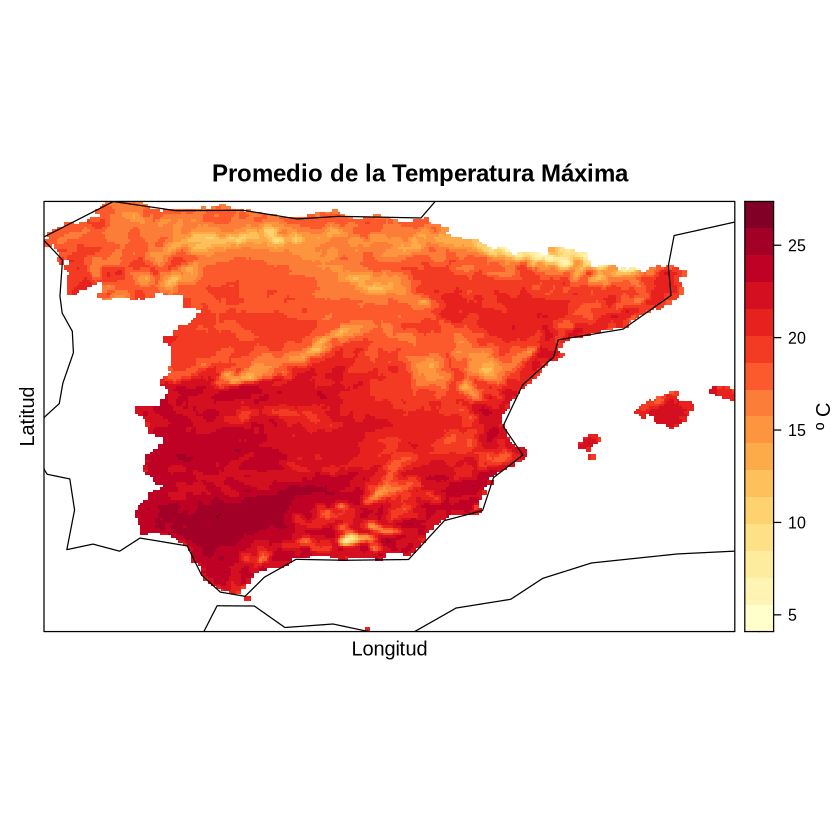

In [11]:
spatialPlot(mean.tmax, main="Promedio de la Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
            )

En vez del promedio, también podemos ver las colas de la distribución, como el percentil 90.

In [12]:
# climatology percentile 90
p90.tmax <- climatology(tasmax.pi, clim.fun = list(FUN = "quantile", probs=0.90, na.rm=TRUE))


[2025-06-16 19:31:03.372983] - Computing climatology...

[2025-06-16 19:31:10.173939] - Done.



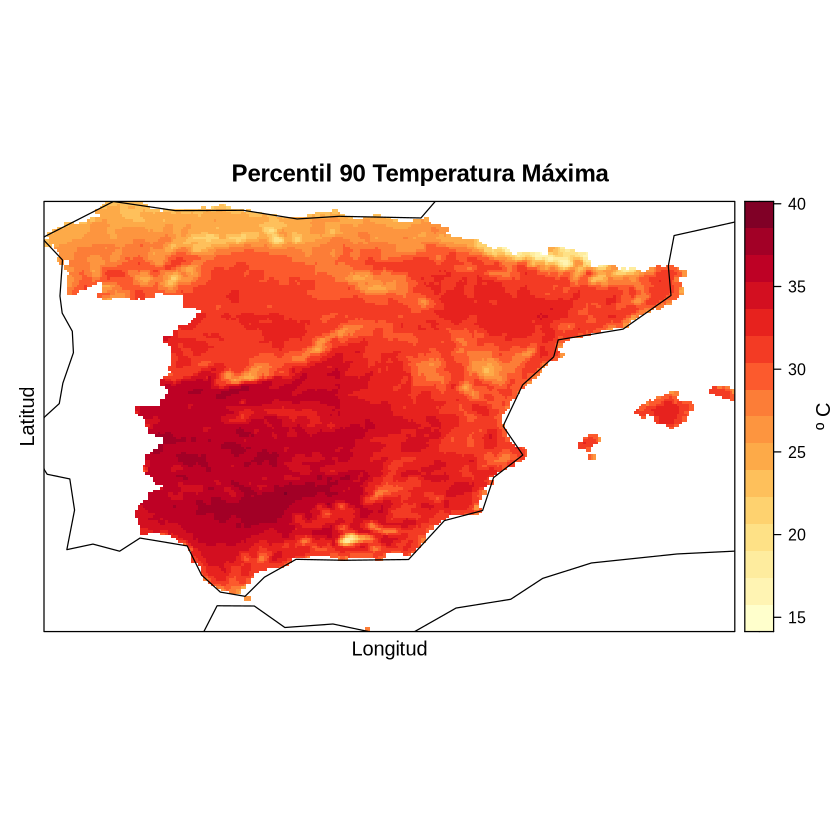

In [13]:
spatialPlot(p90.tmax, main="Percentil 90 Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

Al igual que parámetros estadísticos, también podemos mirar índices. En este caso, vamos a ver cuántos días del año para cada gridbox hay por encima de la temperatura de 35 ºC

In [14]:
idx35 <- tasmax.pi

In [15]:
idx35$Data <- ifelse(idx35$Data >= 35, 1, 0)
attr(idx35$Data, "dimensions") <- c("time", "lat", "lon")

In [16]:
sum.idx <- climatology(idx35, clim.fun = list(FUN = "sum"))

[2025-06-16 19:31:12.34086] - Computing climatology...

[2025-06-16 19:31:13.952617] - Done.



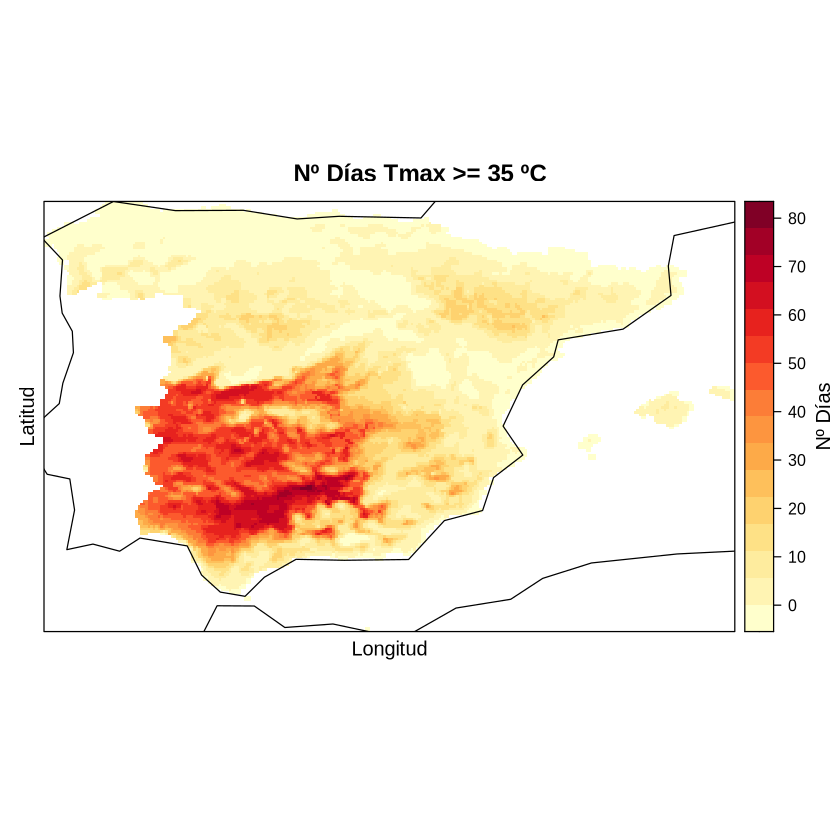

In [17]:
spatialPlot(sum.idx, main="Nº Días Tmax >= 35 ºC", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("Nº Días", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

No solo se puede cargar la variable de temperatura. Como hemos visto antes al ver las variables del dataset, se tienen más. A continuación, cargaremos la precipitación, para ello nos referimos a ella como *pr*

In [19]:
pr.pi <- loadGridData(dataset = lon.pi,
                           var = "pr",
                           years = 2005)

[2025-06-16 19:34:20.642746] Opening dataset...

[2025-06-16 19:34:22.499886] The dataset was successfuly opened

[2025-06-16 19:34:22.507695] Defining geo-location parameters

[2025-06-16 19:34:22.579885] Defining time selection parameters

[2025-06-16 19:34:22.74025] Retrieving data subset ...

[2025-06-16 19:34:32.311435] Done



Para proceder de forma distinta y ver otras funcionalidades del framework y como tratar el dataset vamos a hacer una agregación mensual.

In [20]:
pr.pi.aggr.m <- aggregateGrid(pr.pi, aggr.m=list(FUN="sum"))

[2025-06-16 19:34:33.176] Performing monthly aggregation...

[2025-06-16 19:34:38.072891] Done.



Elegimos dos puntos de la península. Para ver las diferencias he escogido Granada y Santander. De esta manera, al usar la función *subsetGrid*, nos quedamos unicamente con la latitud y longitud seleccionada.

In [21]:
# Granada
lat.g <- 37.1
lon.g <- -3.6

pr.granada.m <- subsetGrid(pr.pi.aggr.m, latLim = lat.g, lonLim = lon.g)

# Santander
lat.s <- 43.5
lon.s <- -3.8

pr.santander.m <- subsetGrid(pr.pi.aggr.m, latLim= lat.s, lonLim = lon.s)

pad applied on the interval: month

pad applied on the interval: month

pad applied on the interval: month



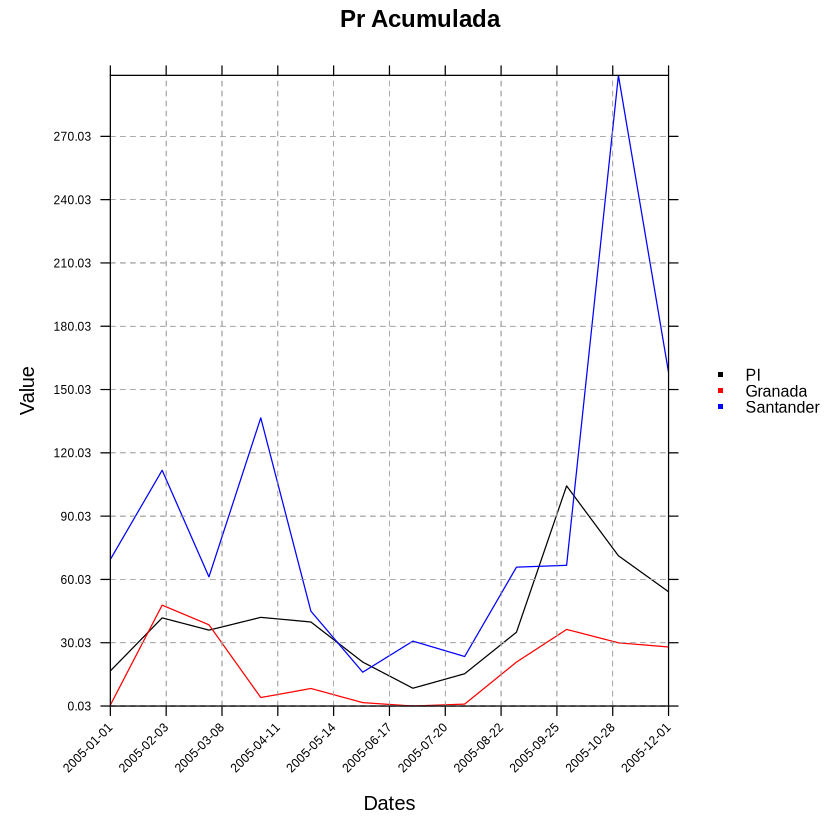

In [22]:
temporalPlot("PI"=pr.pi.aggr.m, "Granada"=pr.granada.m, "Santander"=pr.santander.m, xyplot.custom = list(main = "Pr Acumulada"))

En esta serie temporal (*temporalPlot*) se puede ver en azul la precipitación acumulada para un gridbox correspondiente a Santander, en rojo correspondiente a Badajoz y en negro una media de todos los gridboxes.

In [23]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] visualizeR_1.6.4    transformeR_2.2.2   loadeR_1.8.1       
[4] climate4R.UDG_0.2.6 loadeR.java_1.1.1   rJava_1.0-11       

loaded via a namespace (and not attached):
 [1] dotCall64_1.2           spa